# Ejercicio 1

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import shift

In [3]:
def mutual_information(Img1,Img2):
    """
    Recibe dos imagen en vectores
    """
    
    hist_2d, _, _ = np.histogram2d(Img1, Img2, bins=256)

    p_xy = hist_2d/ len(Img2)
    p_x = np.sum(p_xy,axis=1)
    p_y = np.sum(p_xy,axis=0)
    p_x_p_y = np.outer(p_x,p_y)

    nonzero_mask = p_xy > 0
    
    mi = np.sum(p_xy[nonzero_mask] * np.log2(p_xy[nonzero_mask] / p_x_p_y[nonzero_mask]))
    
    return mi

# Ejercicio 2

Desplazada 1: IM = 0.8676


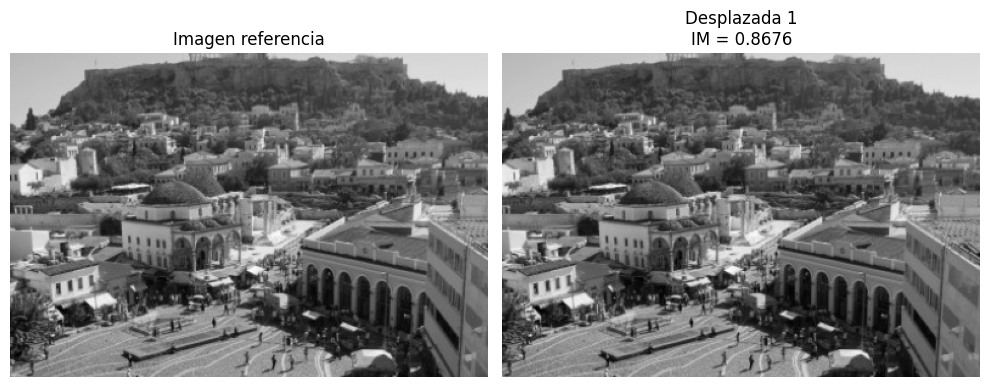

Desplazada 2: IM = 0.7188


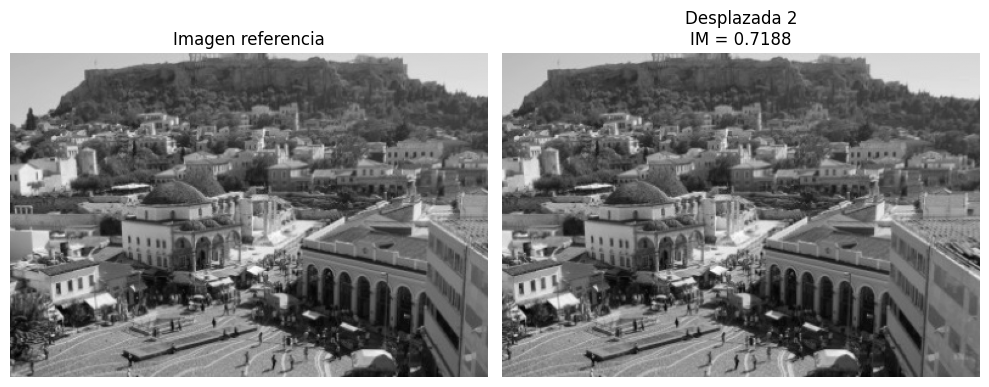

Zoom 1: IM = 0.5096


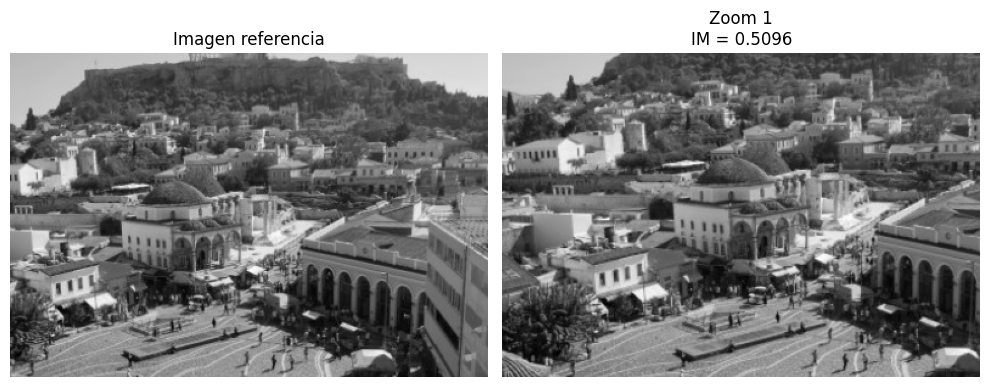

Zoom 2: IM = 0.4268


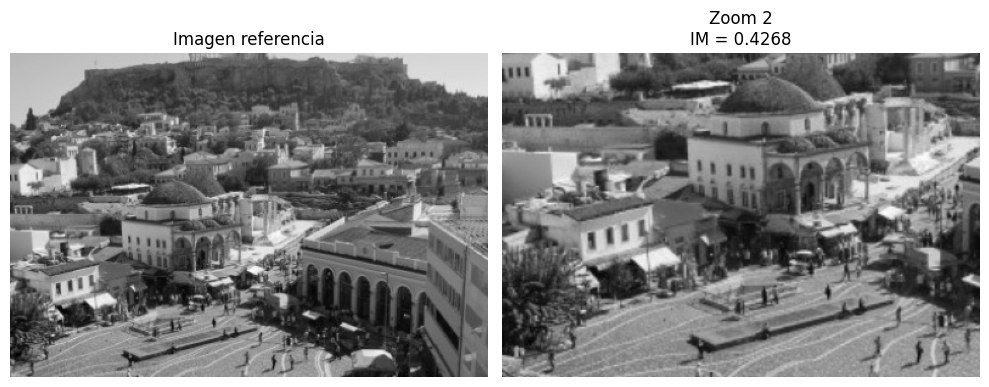

Contraste 1: IM = 3.2745


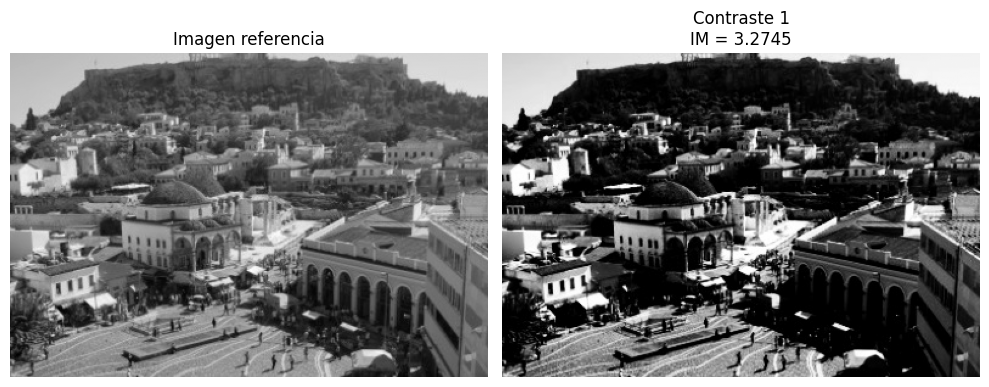

Contraste 2: IM = 0.8163


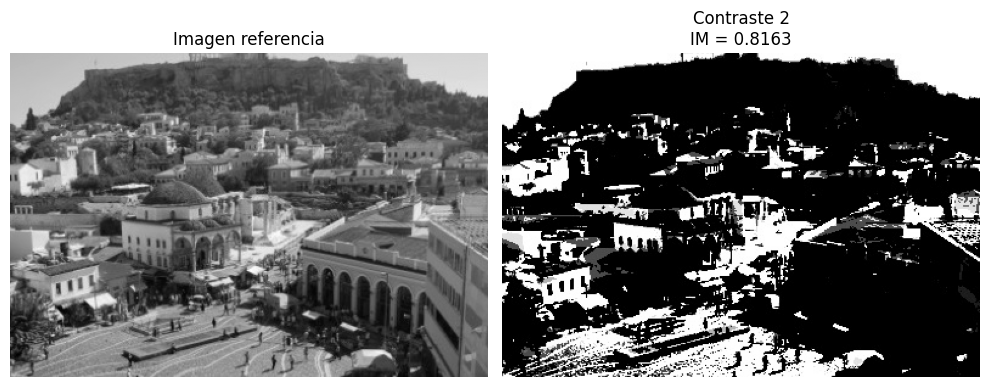

In [4]:
def cargar_y_recortar(path1, path2):
    img1 = cv2.imread(path1, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(path2, cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None:
        raise ValueError("No se pudo cargar una de las imagenes")

    h = min(img1.shape[0], img2.shape[0])
    w = min(img1.shape[1], img2.shape[1])

    img1 = img1[:h, :w]
    img2 = img2[:h, :w]

    return img1, img2, img1.flatten(), img2.flatten()

# Imagen de referencia
img_ref_path = "Imagenes/img01.jpg"

# Imagenes a comparar
imagenes = {
    "Desplazada 1": "Imagenes/img01_desplazada1.jpg",
    "Desplazada 2": "Imagenes/img01_desplazada2.jpg",

    "Zoom 1": "Imagenes/img01_zoom1.jpg",
    "Zoom 2": "Imagenes/img01_zoom2.jpg",

    "Contraste 1": "Imagenes/img01_contraste1.jpg",
    "Contraste 2": "Imagenes/img01_contraste2.jpg"
}

# Calculo y graficos
for titulo, path in imagenes.items():
    img_ref_mostrar, img_mostrar, img_ref_vec, img_vec = cargar_y_recortar(img_ref_path, path)

    # Calcular informacion mutua
    mi = mutual_information(img_ref_vec, img_vec)

    print(f"{titulo}: IM = {mi:.4f}")

    # Graficos
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(img_ref_mostrar, cmap="gray")
    ax[0].set_title("Imagen referencia")
    ax[0].axis("off")

    ax[1].imshow(img_mostrar, cmap="gray")
    ax[1].set_title(f"{titulo}\nIM = {mi:.4f}")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

A partir de los resultados obtenidos se observa que la informacion mutua depende fuertemente del tipo de transformacion aplicada sobre la imagen original.

En primer lugar, para las imagenes desplazadas se obtuvieron valores de 0,8676 para desplazada1 y 0,7188 para desplazada2. Estos valores muestran que, a medida que la imagen se desplaza mas respecto de la imagen original, la informacion mutua disminuye. Esto ocurre porque los pixeles que se comparan dejan de corresponder al mismo punto del objeto o de la escena. Por lo tanto, la relacion estadistica entre las intensidades de ambas imagenes se debilita.

Para las imagenes con zoom, los valores obtenidos fueron 0,5096 para zoom1 y 0,4268 para zoom2. Estos valores son menores que los obtenidos para los desplazamientos. Esto indica que el cambio de escala afecta mas la correspondencia entre pixeles que un desplazamiento moderado. Al aplicar zoom, las estructuras de la imagen cambian de posicion y de tamaño, por lo que la comparacion pixel a pixel con la imagen original pierde consistencia. Por este motivo, la informacion mutua disminuye.

En el caso de las imagenes con contrastes, los valores obtenidos fueron 3,2745 para contraste1 y 0,8163 para contraste2. En contraste1, aunque se modifican los niveles de gris y las zonas oscuras se ven mas marcadas, todavia se conservan la mayoria de las estructuras y detalles de la imagen original. Por eso, la relacion estadistica entre ambas imagenes sigue siendo fuerte y la informacion mutua obtenida es alta. En cambio, en contraste2 los negros se intensifican demasiado y algunos detalles dejan de distinguirse correctamente. Esto hace que se pierda informacion visual y que la comparacion con la imagen original sea menos consistente. Por este motivo, la informacion mutua disminuye.

En general, los resultados muestran que la informacion mutua es alta cuando las imagenes conservan una relacion estadistica clara entre sus intensidades, aunque no sean exactamente iguales. Tambien se observa que las transformaciones geometricas, como desplazamientos y zoom, tienden a reducir la informacion mutua porque rompen la correspondencia espacial entre pixeles.

# Ejercicio 3

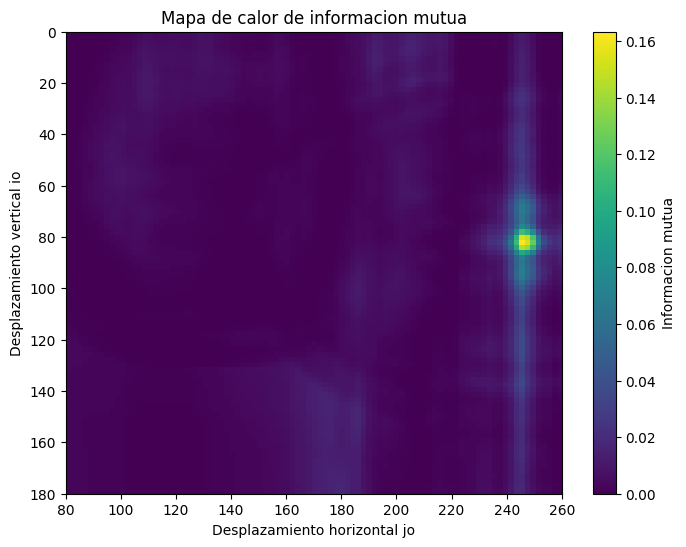

In [5]:
def superponer(img_back: np.ndarray, img_mask: np.ndarray):
    """
    Superpone una máscara binaria en color rojo sobre una imagen de
    referencia. Los píxeles con intensidad cercana a cero en la máscara
    se muestran transparentes, mientras que los restantes se
    visualizan en rojo.
    Parámetros
    ----------
    img_back : Imagen de referencia.
    img_mask : Imagen máscara a superponer.
    """
    fig, ax = plt.subplots()
    ax.imshow(img_back, cmap='gray') # imagen de fondo
    mask = img_mask > 0.1 # mascara binaria
    red_overlay = np.zeros((*img_mask.shape, 4)) # crear imagen RGB roja
    red_overlay[..., 0] = 1.0 # saturar canal rojo
    red_overlay[..., 3] = mask.astype(float) # aplicar trnasparencia
    ax.imshow(red_overlay)
    ax.axis('off')
    plt.show()

def obtener_roi(img, margen=15):
    filas, columnas = np.where(img > 0)

    if len(filas) == 0 or len(columnas) == 0:
        return None

    fila_min = max(np.min(filas) - margen, 0)
    fila_max = min(np.max(filas) + margen, img.shape[0])
    col_min = max(np.min(columnas) - margen, 0)
    col_max = min(np.max(columnas) + margen, img.shape[1])

    return fila_min, fila_max, col_min, col_max


def informacion_mutua_local(img_ref, patron_binario, io, jo, margen=20):
    patron_desplazado = shift(
        patron_binario,
        shift=(io, jo),
        cval=0,
        order=0
    )

    roi = obtener_roi(patron_desplazado, margen=margen)

    if roi is None:
        return 0

    fila_min, fila_max, col_min, col_max = roi

    roi_ref = img_ref[fila_min:fila_max, col_min:col_max]
    roi_patron = patron_desplazado[fila_min:fila_max, col_min:col_max]

    if roi_ref.size == 0 or roi_patron.size == 0:
        return 0

    return mutual_information(roi_ref.flatten(), roi_patron.flatten())


img_ref = cv2.imread("Imagenes/llaves.jpg", cv2.IMREAD_GRAYSCALE)
img_patron = cv2.imread("Imagenes/patron.jpg", cv2.IMREAD_GRAYSCALE)

if img_ref is None or img_patron is None:
    raise ValueError("No se encontro la imagen")

if img_ref.shape != img_patron.shape:
    raise ValueError("Las imagenes deben tener el mismo tamanio")


edges_ref = cv2.Canny(img_ref, 100, 200)
edges_ref = cv2.dilate(edges_ref, np.ones((3, 3), np.uint8), iterations=1)

_, patron_binario = cv2.threshold(img_patron, 10, 255, cv2.THRESH_BINARY)
patron_binario = cv2.dilate(patron_binario, np.ones((3, 3), np.uint8), iterations=1)


io_min = 0
io_max = 180
jo_min = 80
jo_max = 260
paso = 2

valores_io = np.arange(io_min, io_max + 1, paso)
valores_jo = np.arange(jo_min, jo_max + 1, paso)

matriz_mi = np.zeros((len(valores_io), len(valores_jo)))

for i, io in enumerate(valores_io):
    for j, jo in enumerate(valores_jo):
        matriz_mi[i, j] = informacion_mutua_local(
            edges_ref,
            patron_binario,
            io,
            jo,
            margen=20
        )


plt.figure(figsize=(8, 6))
plt.imshow(
    matriz_mi,
    extent=[jo_min, jo_max, io_max, io_min],
    aspect="auto"
)
plt.colorbar(label="Informacion mutua")
plt.xlabel("Desplazamiento horizontal jo")
plt.ylabel("Desplazamiento vertical io")
plt.title("Mapa de calor de informacion mutua")
plt.show()


io optimo: 82
jo optimo: 246
informacion mutua maxima: 0.16325899390932502


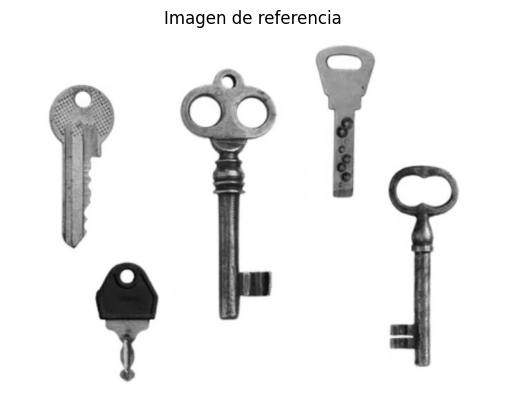

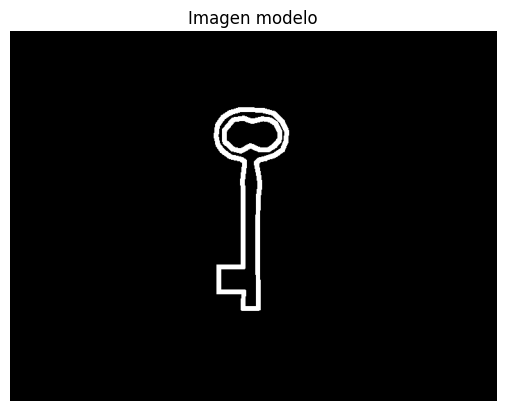

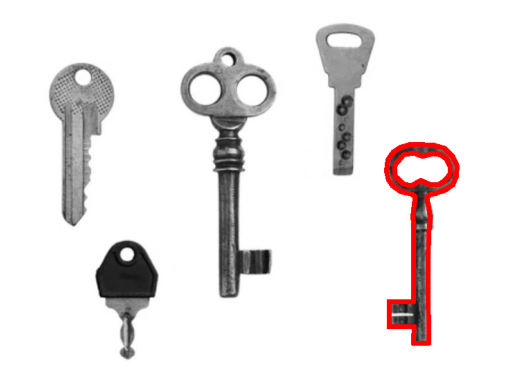

In [6]:
# se busca el mejor desplazamiento
indice_maximo = np.unravel_index(np.argmax(matriz_mi), matriz_mi.shape)

io_optimo = valores_io[indice_maximo[0]]
jo_optimo = valores_jo[indice_maximo[1]]
mi_maxima = matriz_mi[indice_maximo]

print("io optimo:", io_optimo)
print("jo optimo:", jo_optimo)
print("informacion mutua maxima:", mi_maxima)

# patron alineado
patron_alineado = shift(
    patron_binario,
    shift=(io_optimo, jo_optimo),
    cval=0,
    order=0
)


plt.figure()
plt.imshow(img_ref, cmap="gray")
plt.title("Imagen de referencia")
plt.axis("off")
plt.show()

plt.figure()
plt.imshow(patron_binario, cmap="gray")
plt.title("Imagen modelo")
plt.axis("off")
plt.show()

superponer(img_ref, patron_alineado)


El mapa de calor obtenido permite visualizar cómo varía la información mutua entre la imagen de referencia y las desplazadas. Se observa que existe una región definida donde la información mutua alcanza un máximo, indicando la posición en las imágenes presentan la mayor dependencia estadística y, por lo tanto, el mejor alineamiento.

Por otra parte, el análisis de la superficie evidencia algunos desafíos asociados a los problemas de optimización. Dependiendo de las características de las imágenes, pueden existir máximos locales que dificulten la búsqueda de la solución óptima. En este trabajo se evaluó exhaustivamente el espacio de parámetros mediante una grilla de desplazamientos, garantizando la identificación del máximo global dentro del rango analizado. Sin embargo, para imágenes de mayor tamaño o transformaciones más complejas, este enfoque puede resultar muy costoso.

En conclusión, los resultados obtenidos demuestran que la información mutua constituye una herramienta eficaz para el alineamiento de imágenes, ya que permite identificar correctamente la transformación que maximiza la correspondencia entre ambas imágenes. Sin embargo, si una imagen tiene muchos maximos locales o transformaciones complicadas el costo computacional puede ser muy grande.